# Tabular ML Experiment

Edit CONFIG, then run cells from top to bottom.

In [40]:
from pathlib import Path
import sys
import traceback

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import load_data, make_cv_splitter, make_holdout_split, prepare_xy
from src.features import build_preprocessor, prepare_test_features, resolve_preprocess_type
from src.metrics import evaluate, summarize_cv_metrics
from src.models import create_model, train_autogluon
from src.utils import get_model_alias, make_model_dir, make_run_dir, save_config, save_dataframe, save_json, save_pickle, set_seed

In [ ]:
CONFIG = {
    "seed": 42,
    "experiment": {"name": "baseline", "note": "initial comparison"},
    "io": {"input_format": "csv", "model_format": "pickle"},
    "data": {
        "train_path": ROOT / "data/raw/yacht_hydro/yacht_hydro.csv",
        #"test_path": ROOT / "data/raw/test.csv",
        "test_path": None,
        "target_col": "Rr",
        "id_col": "id",
    },
    "features": {
        "drop_cols": ["id"],
        "numerical_cols": "auto",
        "categorical_cols": "auto",
    },
    "split": {
        "cv": True,
        "n_splits": 5,
        "shuffle": True,
        "stratified": True,
        "test_size": 0.2,
        "random_state": 42,
    },
    "task": {"type": "regression"},
    "evaluation": {"metrics": ["rmse", "mae", "r2"], "main_metric": "rmse", "greater_is_better": False},
    "prediction": {"use_proba": True, "threshold": 0.5},
    "models": [
        {"name": "ridge", "alias": "ridge", "enabled": True, "params": {"alpha": 1.0}},
        {"name": "lasso", "alias": "lasso", "enabled": True, "params": {"alpha": 0.001, "max_iter": 10000}},
        {"name": "knn", "alias": "knn", "enabled": True, "params": {"n_neighbors": 5}},
        {"name": "svr", "alias": "svr", "enabled": True, "params": {"C": 1.0, "epsilon": 0.1}},
        {
            "name": "mlp",
            "alias": "mlp",
            "enabled": True,
            "params": {"hidden_layer_sizes": (64, 32), "max_iter": 500, "random_state": 42},
        },
        {
            "name": "random_forest",
            "alias": "random_forest",
            "enabled": True,
            "params": {"n_estimators": 300, "random_state": 42, "n_jobs": -1},
        },
        {
            "name": "extra_trees",
            "alias": "extra_trees",
            "enabled": True,
            "params": {"n_estimators": 300, "random_state": 42, "n_jobs": -1},
        },
        {
            "name": "xgboost",
            "alias": "xgboost",
            "enabled": True,
            "params": {"n_estimators": 500, "learning_rate": 0.05, "max_depth": 6, "random_state": 42, "n_jobs": -1},
        },
        {
            "name": "lightgbm",
            "alias": "lightgbm",
            "enabled": True,
            "params": {"n_estimators": 500, "learning_rate": 0.05, "num_leaves": 31, "random_state": 42, "n_jobs": -1},
        },
        {
            "name": "catboost",
            "alias": "catboost",
            "enabled": True,
            "params": {"iterations": 500, "learning_rate": 0.05, "depth": 6, "random_seed": 42},
        },
        {"name": "tabpfn", "alias": "tabpfn", "enabled": False, "params": {}},
        {"name": "autogluon", "alias": "autogluon", "enabled": False, "params": {}},
    ],
    "output": {"save_models": True, "save_preprocessors": True, "save_oof": True, "save_test_predictions": True},
    "run": {"continue_on_error": True},
}

In [42]:
set_seed(CONFIG["seed"])
train_df, test_df = load_data(CONFIG)
X, y = prepare_xy(train_df, CONFIG)
X_test = prepare_test_features(test_df, CONFIG)

run_dir = make_run_dir(ROOT / "outputs")
save_config(CONFIG, run_dir / "summary/config.json")
print(f"Run directory: {run_dir}")

Run directory: /mount/moritadbjp/sharefilesjp/work/tabML/outputs/20260524-8mdd


In [43]:
comparison_rows = []
task_type = CONFIG["task"]["type"]
is_regression = task_type == "regression"
main_metric = CONFIG["evaluation"]["main_metric"]
id_col = CONFIG["data"].get("id_col")

for model_config in CONFIG["models"]:
    model_name = model_config["name"]
    alias = get_model_alias(model_config)
    if not model_config.get("enabled", True):
        comparison_rows.append({"model": model_name, "alias": alias, "status": "skipped", "main_metric": np.nan, "error_message": ""})
        continue

    model_dir = make_model_dir(run_dir, alias)
    save_json(model_config, model_dir / "reports/model_config.json")

    try:
        if model_name == "autogluon":
            train_autogluon(train_df, CONFIG, model_dir / "models")
            comparison_rows.append({"model": model_name, "alias": alias, "status": "success", "main_metric": np.nan, "error_message": ""})
            continue

        preprocess_type = resolve_preprocess_type(model_name, CONFIG, model_config)
        output_config = CONFIG.get("output", {})
        use_proba = bool(CONFIG.get("prediction", {}).get("use_proba", False)) and not is_regression
        threshold = CONFIG.get("prediction", {}).get("threshold", 0.5)

        if CONFIG["split"].get("cv", True):
            splitter, split_y = make_cv_splitter(CONFIG, y)
            fold_metrics = []
            oof_pred = pd.Series(index=X.index, dtype="float64" if is_regression else "object")
            oof_fold = pd.Series(index=X.index, dtype="Int64")
            oof_proba = None
            classes = None
            test_fold_predictions = []

            for fold, (train_idx, valid_idx) in enumerate(splitter.split(X, split_y)):
                X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
                y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
                preprocessor = build_preprocessor(X_train, CONFIG, preprocess_type)
                X_train_p = X_train if preprocessor is None else preprocessor.fit_transform(X_train)
                X_valid_p = X_valid if preprocessor is None else preprocessor.transform(X_valid)

                model = create_model(CONFIG, model_config)
                model.fit(X_train_p, y_train)

                valid_proba = None
                if is_regression:
                    valid_pred = model.predict(X_valid_p)
                elif use_proba and hasattr(model, "predict_proba"):
                    valid_proba = model.predict_proba(X_valid_p)
                    classes = getattr(model, "classes_", np.arange(valid_proba.shape[1]))
                    if oof_proba is None:
                        oof_proba = np.zeros((len(y), valid_proba.shape[1]))
                    oof_proba[valid_idx, :] = valid_proba
                    valid_pred = np.where(valid_proba[:, 1] >= threshold, classes[1], classes[0]) if len(classes) == 2 else classes[np.argmax(valid_proba, axis=1)]
                else:
                    valid_pred = model.predict(X_valid_p)

                oof_pred.iloc[valid_idx] = valid_pred
                oof_fold.iloc[valid_idx] = fold
                metrics = evaluate(y_valid, valid_pred, CONFIG, valid_proba)
                fold_metrics.append({"fold": fold, **metrics})

                if output_config.get("save_models", True):
                    save_pickle(model, model_dir / f"models/fold{fold}_model.pkl")
                if output_config.get("save_preprocessors", True) and preprocessor is not None:
                    save_pickle(preprocessor, model_dir / f"models/fold{fold}_preprocessor.pkl")

                if X_test is not None and output_config.get("save_test_predictions", True):
                    X_test_p = X_test if preprocessor is None else preprocessor.transform(X_test)
                    if is_regression:
                        test_fold_predictions.append(model.predict(X_test_p))
                    elif use_proba and hasattr(model, "predict_proba"):
                        test_fold_predictions.append(model.predict_proba(X_test_p))
                    else:
                        test_fold_predictions.append(model.predict(X_test_p))

            summary_metrics = summarize_cv_metrics(fold_metrics, main_metric)
            save_dataframe(pd.DataFrame(fold_metrics), model_dir / "predictions/fold_metrics.csv")
            save_json(summary_metrics, model_dir / "reports/metrics.json")

            if output_config.get("save_oof", True):
                oof_df = pd.DataFrame({"y_true": y, "prediction": oof_pred, "fold": oof_fold})
                if id_col and id_col in train_df.columns:
                    oof_df.insert(0, id_col, train_df[id_col].values)
                if oof_proba is not None:
                    for i, cls in enumerate(classes):
                        oof_df[f"proba_{cls}"] = oof_proba[:, i]
                save_dataframe(oof_df, model_dir / "predictions/oof_predictions.csv")

            if X_test is not None and test_fold_predictions and output_config.get("save_test_predictions", True):
                test_df_out = pd.DataFrame()
                if id_col and test_df is not None and id_col in test_df.columns:
                    test_df_out[id_col] = test_df[id_col].values
                if is_regression:
                    test_df_out["prediction"] = np.mean(test_fold_predictions, axis=0)
                elif use_proba and hasattr(model, "predict_proba"):
                    mean_proba = np.mean(test_fold_predictions, axis=0)
                    for i, cls in enumerate(classes):
                        test_df_out[f"proba_{cls}"] = mean_proba[:, i]
                    test_df_out["prediction"] = np.where(mean_proba[:, 1] >= threshold, classes[1], classes[0]) if len(classes) == 2 else classes[np.argmax(mean_proba, axis=1)]
                else:
                    test_df_out["prediction"] = pd.DataFrame(test_fold_predictions).mode(axis=0).iloc[0].values
                save_dataframe(test_df_out, model_dir / "predictions/test_predictions.csv")

        else:
            X_train, X_valid, y_train, y_valid = make_holdout_split(X, y, CONFIG)
            preprocessor = build_preprocessor(X_train, CONFIG, preprocess_type)
            X_train_p = X_train if preprocessor is None else preprocessor.fit_transform(X_train)
            X_valid_p = X_valid if preprocessor is None else preprocessor.transform(X_valid)
            model = create_model(CONFIG, model_config)
            model.fit(X_train_p, y_train)

            valid_proba = None
            if is_regression:
                valid_pred = model.predict(X_valid_p)
            elif use_proba and hasattr(model, "predict_proba"):
                valid_proba = model.predict_proba(X_valid_p)
                classes = getattr(model, "classes_", np.arange(valid_proba.shape[1]))
                valid_pred = np.where(valid_proba[:, 1] >= threshold, classes[1], classes[0]) if len(classes) == 2 else classes[np.argmax(valid_proba, axis=1)]
            else:
                valid_pred = model.predict(X_valid_p)

            summary_metrics = evaluate(y_valid, valid_pred, CONFIG, valid_proba)
            save_json(summary_metrics, model_dir / "reports/metrics.json")
            valid_df = pd.DataFrame({"y_true": y_valid, "prediction": valid_pred})
            save_dataframe(valid_df, model_dir / "predictions/valid_predictions.csv")
            if output_config.get("save_models", True):
                save_pickle(model, model_dir / "models/model.pkl")
            if output_config.get("save_preprocessors", True) and preprocessor is not None:
                save_pickle(preprocessor, model_dir / "models/preprocessor.pkl")
            if X_test is not None and output_config.get("save_test_predictions", True):
                X_test_p = X_test if preprocessor is None else preprocessor.transform(X_test)
                test_df_out = pd.DataFrame()
                if id_col and test_df is not None and id_col in test_df.columns:
                    test_df_out[id_col] = test_df[id_col].values
                if is_regression:
                    test_df_out["prediction"] = model.predict(X_test_p)
                elif use_proba and hasattr(model, "predict_proba"):
                    test_proba = model.predict_proba(X_test_p)
                    for i, cls in enumerate(classes):
                        test_df_out[f"proba_{cls}"] = test_proba[:, i]
                    test_df_out["prediction"] = np.where(test_proba[:, 1] >= threshold, classes[1], classes[0]) if len(classes) == 2 else classes[np.argmax(test_proba, axis=1)]
                else:
                    test_df_out["prediction"] = model.predict(X_test_p)
                save_dataframe(test_df_out, model_dir / "predictions/test_predictions.csv")

        comparison_rows.append({"model": model_name, "alias": alias, "status": "success", "main_metric": summary_metrics.get(main_metric, np.nan), **summary_metrics, "error_message": ""})

    except Exception as exc:
        error_text = traceback.format_exc()
        save_json({"error_message": str(exc), "traceback": error_text}, model_dir / "reports/error.json")
        comparison_rows.append({"model": model_name, "alias": alias, "status": "failed", "main_metric": np.nan, "error_message": str(exc)})
        if not CONFIG.get("run", {}).get("continue_on_error", True):
            raise

comparison_df = pd.DataFrame(comparison_rows)
save_dataframe(comparison_df, run_dir / "summary/model_comparison.csv")
comparison_df

/mount/moritadbjp/sharefilesjp/work/tabML/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/mount/moritadbjp/sharefilesjp/work/tabML/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/mount/moritadbjp/sharefilesjp/work/tabML/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/mount/moritadbjp/sharefilesjp/work/tabML/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reac

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 69
[LightGBM] [Info] Number of data points in the train set: 246, number of used features: 6
[LightGBM] [Info] Start training from score 10.597114
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/mount/moritadbjp/sharefilesjp/work/tabML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/mount/moritadbjp/sharefilesjp/work/tabML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mount/moritadbjp/sharefilesjp/work/tabML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/mount/moritadbjp/sharefilesjp/work/tabML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000054 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 69
[LightGBM] [Info] Number of data points in the train set: 247, number of used features: 6
[LightGBM] [Info] Start training from score 10.651538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/mount/moritadbjp/sharefilesjp/work/tabML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,alias,status,main_metric,fold,rmse,mae,r2,error_message
0,ridge,ridge,success,9.167208,2.0,9.167208,7.351803,0.630956,
1,lasso,lasso,success,9.177826,2.0,9.177826,7.372074,0.630081,
2,knn,knn,success,10.819441,2.0,10.819441,5.634442,0.487446,
3,svr,svr,success,12.551006,2.0,12.551006,5.961675,0.310918,
4,mlp,mlp,success,1.787292,2.0,1.787292,0.973017,0.985584,
5,random_forest,random_forest,success,1.036785,2.0,1.036785,0.517775,0.995066,
6,extra_trees,extra_trees,success,1.073751,2.0,1.073751,0.536294,0.994550,
7,xgboost,xgboost,success,0.981498,2.0,0.981498,0.429370,0.995334,
8,lightgbm,lightgbm,success,4.713607,2.0,4.713607,1.984411,0.900746,
9,catboost,catboost,success,1.867809,2.0,1.867809,0.707630,0.982466,


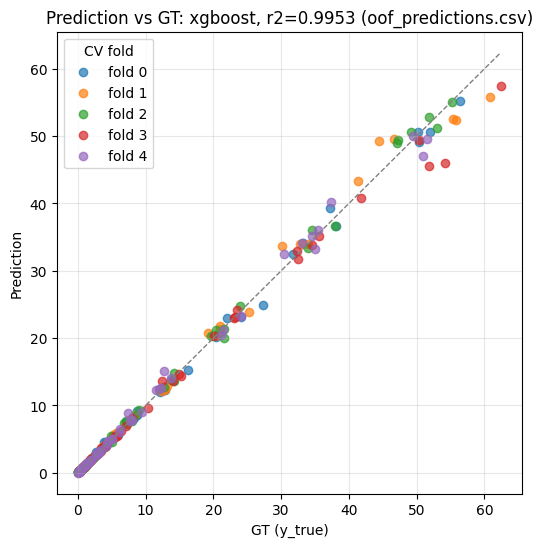

In [44]:
import matplotlib.pyplot as plt

successful = comparison_df[comparison_df["status"] == "success"].copy()
if successful.empty:
    raise ValueError("No successful model result found in comparison_df.")

if "r2" in successful.columns and successful["r2"].notna().any():
    best_row = successful.loc[successful["r2"].astype(float).idxmax()]
else:
    best_row = successful.iloc[0]

alias = best_row["alias"]
prediction_dir = run_dir / alias / "predictions"
oof_path = prediction_dir / "oof_predictions.csv"
valid_path = prediction_dir / "valid_predictions.csv"

if oof_path.exists():
    plot_df = pd.read_csv(oof_path)
    plot_source = oof_path.name
elif valid_path.exists():
    plot_df = pd.read_csv(valid_path)
    plot_source = valid_path.name
else:
    raise FileNotFoundError("oof_predictions.csv or valid_predictions.csv was not found.")

if not {"y_true", "prediction"}.issubset(plot_df.columns):
    raise ValueError("Prediction file must contain y_true and prediction columns.")

fig, ax = plt.subplots(figsize=(6, 6))
if "fold" in plot_df.columns and plot_df["fold"].notna().any():
    for fold, fold_df in plot_df.groupby("fold", dropna=True):
        ax.scatter(fold_df["y_true"], fold_df["prediction"], alpha=0.7, label=f"fold {int(fold)}")
    ax.legend(title="CV fold")
else:
    ax.scatter(plot_df["y_true"], plot_df["prediction"], alpha=0.7)

if pd.api.types.is_numeric_dtype(plot_df["y_true"]) and pd.api.types.is_numeric_dtype(plot_df["prediction"]):
    min_value = min(plot_df["y_true"].min(), plot_df["prediction"].min())
    max_value = max(plot_df["y_true"].max(), plot_df["prediction"].max())
    ax.plot([min_value, max_value], [min_value, max_value], linestyle="--", color="gray", linewidth=1)

r2_text = f", r2={best_row['r2']:.4f}" if "r2" in successful.columns and pd.notna(best_row.get("r2")) else ""
ax.set_xlabel("GT (y_true)")
ax.set_ylabel("Prediction")
ax.set_title(f"Prediction vs GT: {alias}{r2_text} ({plot_source})")
ax.grid(True, alpha=0.3)
plt.show()


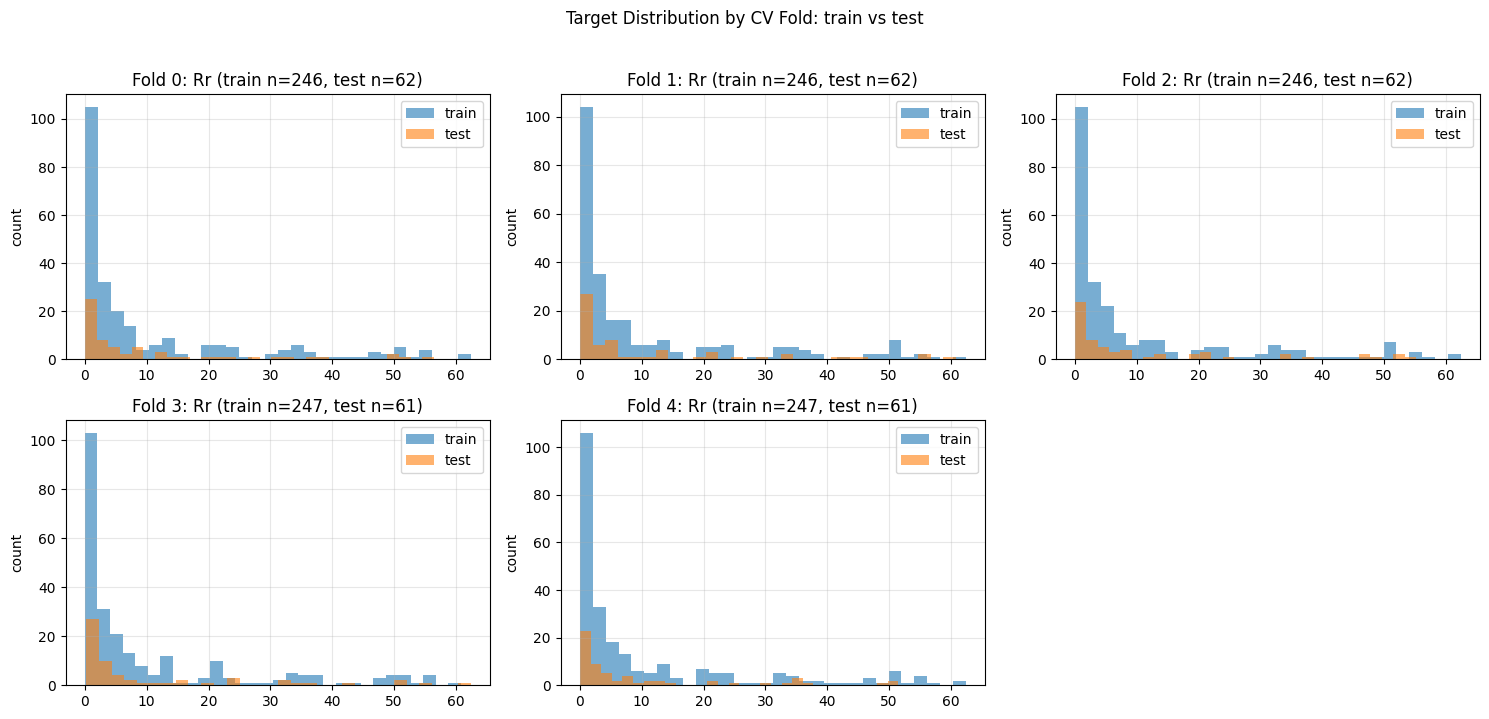

In [45]:
import math
import matplotlib.pyplot as plt

if "y" not in globals() or y is None:
    raise ValueError("Run the data loading cell before plotting target distributions.")

target_col = CONFIG["data"].get("target_col", "target")
is_numeric_target = pd.api.types.is_numeric_dtype(y)

if CONFIG["split"].get("cv", True):
    splitter, split_y = make_cv_splitter(CONFIG, y)
    fold_splits = list(splitter.split(X, split_y))
    n_plots = len(fold_splits)
    n_cols = min(3, n_plots)
    n_rows = math.ceil(n_plots / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for fold, (train_idx, valid_idx) in enumerate(fold_splits):
        ax = axes[fold]
        y_train_fold = y.iloc[train_idx]
        y_valid_fold = y.iloc[valid_idx]
        train_n = len(y_train_fold)
        test_n = len(y_valid_fold)

        if is_numeric_target:
            ax.hist(y_train_fold.dropna(), bins=30, alpha=0.6, label="train")
            ax.hist(y_valid_fold.dropna(), bins=30, alpha=0.6, label="test")
            ax.set_ylabel("count")
        else:
            train_counts = y_train_fold.astype(str).value_counts()
            valid_counts = y_valid_fold.astype(str).value_counts()
            dist_df = pd.DataFrame({"train": train_counts, "test": valid_counts}).fillna(0)
            dist_df.plot(kind="bar", ax=ax, alpha=0.75)
            ax.set_ylabel("count")
            ax.tick_params(axis="x", labelrotation=45)

        ax.set_title(f"Fold {fold}: {target_col} (train n={train_n}, test n={test_n})")
        ax.legend()
        ax.grid(True, alpha=0.3)

    for ax in axes[n_plots:]:
        ax.axis("off")

    fig.suptitle("Target Distribution by CV Fold: train vs test", y=1.02)
    fig.tight_layout()
    plt.show()
else:
    X_train_plot, X_test_plot, y_train_plot, y_test_plot = make_holdout_split(X, y, CONFIG)
    train_n = len(y_train_plot)
    test_n = len(y_test_plot)
    fig, ax = plt.subplots(figsize=(6, 4))

    if is_numeric_target:
        ax.hist(y_train_plot.dropna(), bins=30, alpha=0.6, label="train")
        ax.hist(y_test_plot.dropna(), bins=30, alpha=0.6, label="test")
        ax.set_ylabel("count")
    else:
        train_counts = y_train_plot.astype(str).value_counts()
        test_counts = y_test_plot.astype(str).value_counts()
        dist_df = pd.DataFrame({"train": train_counts, "test": test_counts}).fillna(0)
        dist_df.plot(kind="bar", ax=ax, alpha=0.75)
        ax.set_ylabel("count")
        ax.tick_params(axis="x", labelrotation=45)

    ax.set_title(f"Target Distribution: {target_col} (train n={train_n}, test n={test_n})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
